<a href="https://colab.research.google.com/github/samyssr/machine-learning-labs/blob/main/DBSCAN_and_HDBSCAN_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Two clustering models using data curated by StatCan containing the names, types, and locations of cultural and art facilities across Canada. We'll focus on the museum locations provided across Canada.

In [ ]:
!pip install -q hdbscan geopandas contextily shapely

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import StandardScaler

import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

import warnings
warnings.filterwarnings('ignore')

Canada map for reference

In [ ]:
import requests
import zipfile
import io
import os

# URL of the ZIP file on the cloud server
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

# Directory to save the extracted TIFF file
output_dir = './'
os.makedirs(output_dir, exist_ok=True)

# Step 1: Download the ZIP file
response = requests.get(zip_file_url)
response.raise_for_status()  # Ensure the request was successful
# Step 2: Open the ZIP file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    # Step 3: Iterate over the files in the ZIP
    for file_name in zip_ref.namelist():
        if file_name.endswith('.tif'):  # Check if it's a TIFF file
            # Step 4: Extract the TIFF file
            zip_ref.extract(file_name, output_dir)
            print(f"Downloaded and extracted: {file_name}")

Downloaded and extracted: Canada.tif


In [ ]:
def plot_clustered_locations(df, title='Museums Clustered by Proximity'):
    # Carrega coordenadas no GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326")

    # Repjeta para Web Mercator
    gdf = gdf.to_crs(epsg=3857)

    # Cria a figura
    fig, ax = plt.subplots(figsize=(15, 10))

    # Separa ruído de clusters
    non_noise = gdf[gdf['Cluster'] != -1]
    noise = gdf[gdf['Cluster'] == -1]

    # Plota ruído e clusters
    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise')
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6)

    # Adiciona mapa de fundo
    ctx.add_basemap(ax, source='./Canada.tif', zoom=4)

    # Formatação final
    plt.title(title)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

In [ ]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'
df = pd.read_csv(url, encoding = "ISO-8859-1")
df.head()

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766


In [ ]:
# Contagem da distribuição de categorias no dataset (EDA)
df['ODCAF_Facility_Type'].value_counts()

,count
ODCAF_Facility_Type,
library or archives,3013
museum,1938
gallery,810
heritage or historic site,620
theatre/performance and concert hall,583
festival site,346
miscellaneous,343
art or cultural centre,225
artist,94


In [ ]:
# Filtra apenas os registros onde a coluna ODCAF_Facility_Type é 'museum'
df_museums = df[df['ODCAF_Facility_Type'] == 'museum'].copy()

# Remove eventuais linhas sem coordenadas de Latitude ou Longitude
df_museums = df_museums.dropna(subset=['Latitude', 'Longitude'])

# Inspeciona as dimensões e as primeiras linhas
print(f"Total de museus válidos: {len(df_museums)}")
df_museums.head()

Total de museus válidos: 1938


,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
8,10,12 Service Battalion Museum,military museum or fort,museum,canadian museums association,..,5500,no 4 rd,V6X 3L5,richmond,bc,5500 no. 4 rd the sherman armoury richmond bri...,Richmond,5915015,59,49.1763542,-123.112783
13,15,15th Field Artillery Regiment Museum And Archives,museum/gallery,museum,vancouver,..,2025,11th av w,V6J 2C7,vancouver,bc,2025 w 11th av vancouver bc v6j 2c7,Vancouver,5915022,59,49.261938,-123.151123
15,18,17 Wing Heritage Collection,aeronautics and space museum transportation mu...,museum,canadian museums association,..,..,..,R3J 3Y5,winnipeg,mb,air heritage park air force way winnipeg manit...,Winnipeg,4611040,46,49.88955855,-97.23574396


In [ ]:
# Converte Latitude e Longitude para float, transformando textos inválidos em NaN
df_museums['Latitude'] = pd.to_numeric(df_museums['Latitude'], errors='coerce')
df_museums['Longitude'] = pd.to_numeric(df_museums['Longitude'], errors='coerce')

# Remove qualquer registro que tenha ficado NaN após a conversão
df_museums = df_museums.dropna(subset=['Latitude', 'Longitude'])

# Confirma os tipos das colunas
print(df_museums[['Latitude', 'Longitude']].dtypes)

Latitude     float64
Longitude    float64
dtype: object


Building a DBSCAN model

In [ ]:
# Converte coordenadas para numérico tratando valores ausentes e remove nulos
df[['Latitude', 'Longitude']] = df[['Latitude', 'Longitude']].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['Latitude', 'Longitude'])

In [ ]:
# 1. Ajuste de escala da Latitude
coords_scaled = df[['Latitude', 'Longitude']].copy()
coords_scaled['Latitude'] = 2 * coords_scaled['Latitude']

# 2. Instanciação e treinamento do DBSCAN
dbscan = DBSCAN(eps=1.0, min_samples=3, metric='euclidean')

# 3. Atribuição dos clusters e visualização da contagem
df['Cluster'] = dbscan.fit_predict(coords_scaled)
df['Cluster'].value_counts()

,count
Cluster,
0,4643
2,829
10,515
3,269
7,171
-1,84
14,25
26,21
6,20


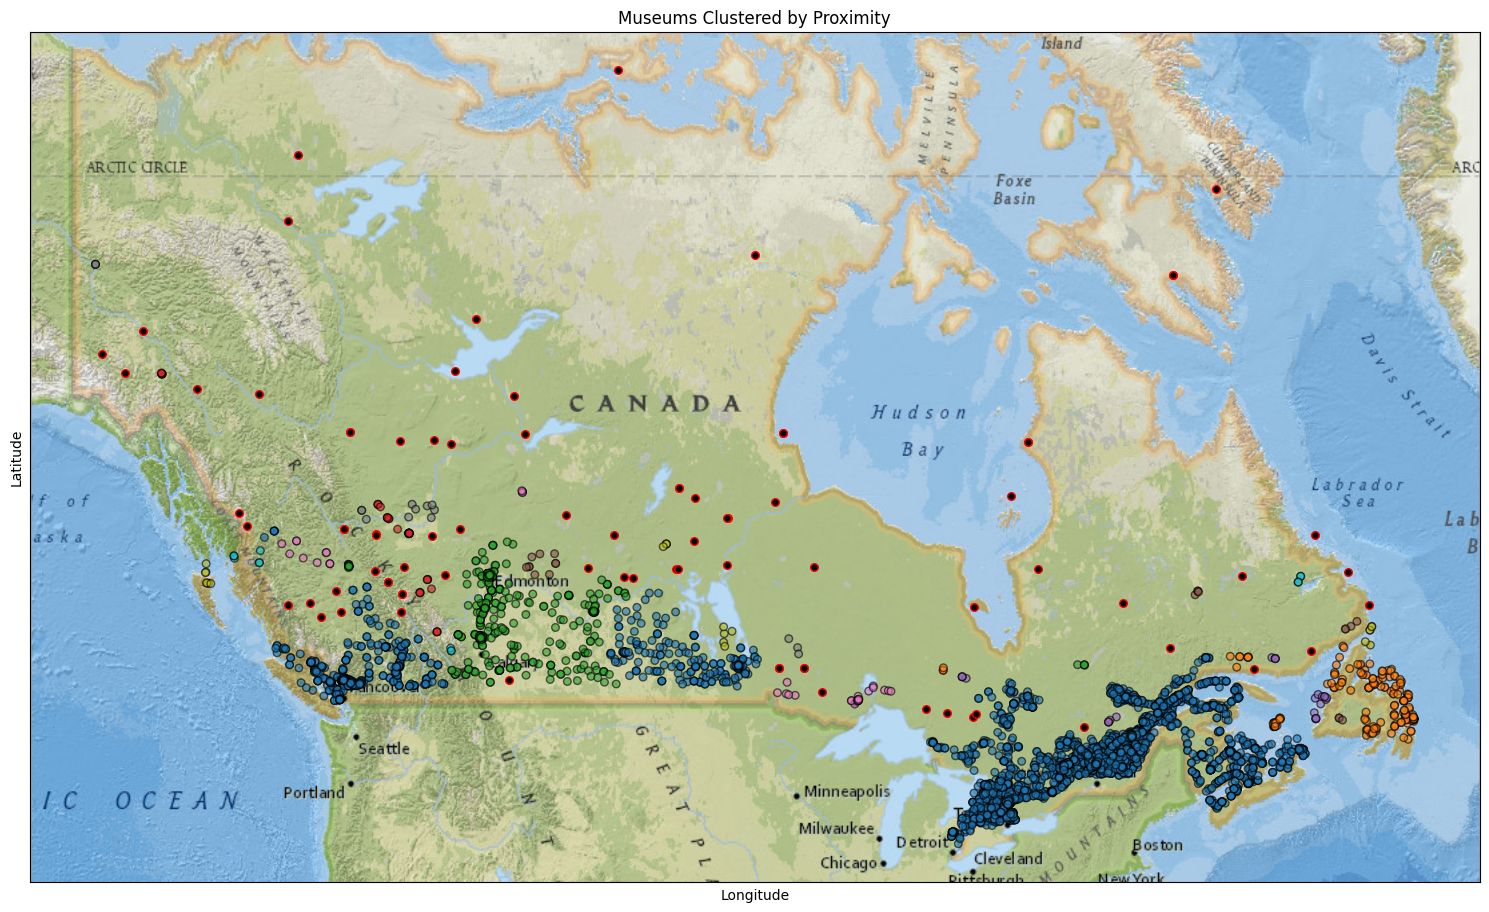

In [ ]:
plot_clustered_locations(df, title='Museums Clustered by Proximity')

In [ ]:
# Filtra apenas os clusters válidos e pega o menor tamanho encontrado
menor_tamanho = df[df['Cluster'] != -1]['Cluster'].value_counts().min()
print(f"Tamanho do menor cluster: {menor_tamanho}")

Tamanho do menor cluster: 3


Building a HDBSCAN model

In [ ]:
min_samples=None
min_cluster_size=3
hdb = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size, metric='euclidean')  # You can adjust parameters as needed

In [ ]:
# 1. Aplica o HDBSCAN nas coordenadas originais (Latitude e Longitude)
df['Cluster'] = hdb.fit_predict(df[['Latitude', 'Longitude']])

# 2. Exibe o tamanho de cada cluster encontrado
df['Cluster'].value_counts()

,count
Cluster,
-1,2016
343,77
242,52
592,43
391,37
...,...
101,3
152,3
48,3


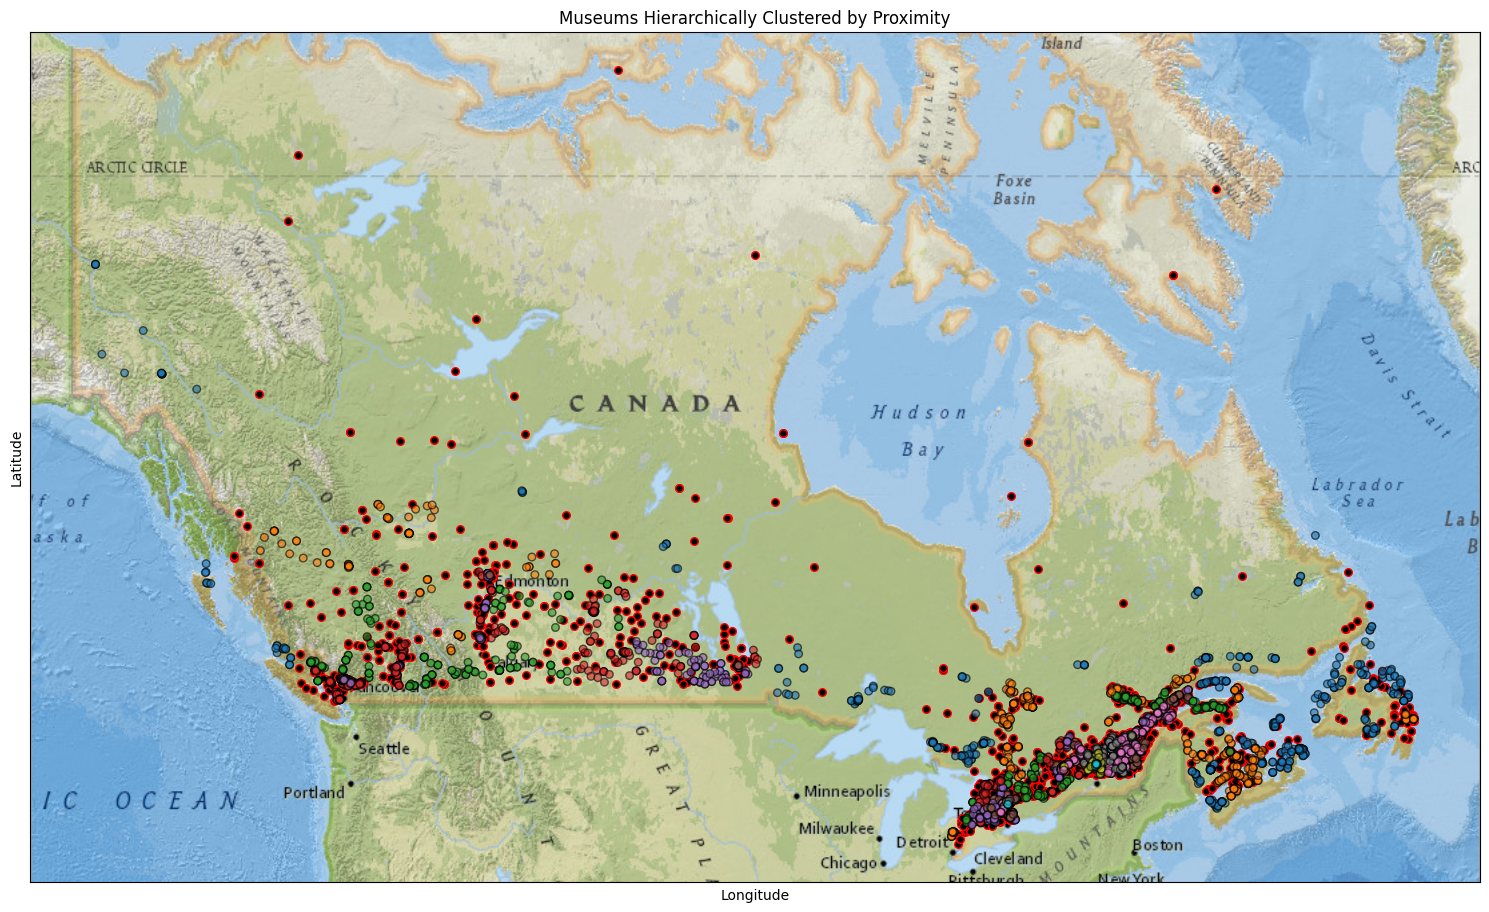

In [ ]:
# Plota o mapa com os clusters do HDBSCAN
plot_clustered_locations(df, title='Museums Hierarchically Clustered by Proximity')

Conclusão e Análise dos Modelos: Neste estudo comparativo entre DBSCAN e HDBSCAN para agrupamento geoespacial dos museus do Canadá, observou-se que:Limitação do DBSCAN: Por utilizar um raio de busca fixo ($\varepsilon$), o algoritmo fundiu grandes regiões metropolitanas vizinhas (como Toronto, Ottawa e Montreal) em uma única mancha massiva, além de se mostrar sensível à necessidade de escalonamento manual das coordenadas.Vantagem do HDBSCAN: Ao avaliar a persistência dos agrupamentos em diferentes níveis de densidade de forma hierárquica, o HDBSCAN identificou com precisão polos urbanos independentes e separou eficientemente as instituições culturais isoladas no interior como ruído (-1), sem exigir a definição rígida de um raio global.O HDBSCAN provou ser a abordagem superior e mais realista para dados geoespaciais com variações naturais de densidade populacional.